In [4]:
#Librerías
from google.colab import drive
import pandas as pd

## Se cargan los datos de entrenamiento

In [5]:
drive.mount('/content/drive')

ruta = '/content/No tratado.csv'
dataset_original = pd.read_csv(ruta,encoding='Latin-1')

Mounted at /content/drive


FileNotFoundError: [Errno 2] No such file or directory: '/content/No tratado.csv'

## Visualización de features

In [ ]:
print(dataset_original.shape)
print(dataset_original.info())
#list(dataset_original.columns)

(1705, 330)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Columns: 330 entries, _STATE to _AIDTST3
dtypes: float64(324), int64(4), object(2)
memory usage: 4.3+ MB
None


In [ ]:
#Figuran solo 328 características porque 2 de las 330 son "objects"
dataset_original.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
_STATE,1705.0,1.000000e+00,0.000000e+00,1.0,1.0,1.0,1.0,1.0
FMONTH,1705.0,2.498534e+00,1.550830e+00,1.0,1.0,2.0,3.0,6.0
IDATE,1705.0,2.715006e+06,1.488766e+06,1032015.0,1262015.0,2222015.0,3252015.0,6292015.0
IMONTH,1705.0,2.578299e+00,1.518624e+00,1.0,1.0,2.0,3.0,6.0
IDAY,1705.0,1.346921e+01,8.558780e+00,1.0,6.0,11.0,21.0,31.0
...,...,...,...,...,...,...,...,...
_RFSEAT2,1704.0,1.732981e+00,2.250009e+00,1.0,1.0,1.0,1.0,9.0
_RFSEAT3,1704.0,1.777582e+00,2.244940e+00,1.0,1.0,1.0,1.0,9.0
_FLSHOT6,866.0,2.081986e+00,2.284701e+00,1.0,1.0,1.0,2.0,9.0
_PNEUMO2,866.0,2.258661e+00,2.581853e+00,1.0,1.0,1.0,2.0,9.0


from matplotlib import pyplot as plt
_df_0['count'].plot(kind='hist', bins=20, title='count')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['mean'].plot(kind='hist', bins=20, title='mean')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['std'].plot(kind='hist', bins=20, title='std')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['min'].plot(kind='hist', bins=20, title='min')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
_df_7.plot(kind='scatter', x='min', y='25%', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_8['count'].plot(kind='line', figsize=(8, 4), title='count')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_9['mean'].plot(kind='line', figsize=(8, 4), title='mean')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_10['std'].plot(kind='line', figsize=(8, 4), title='std')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_11['min'].plot(kind='line', figsize=(8, 4), title='min')
plt.gca().spines[['top', 'right']].set_visible(False)

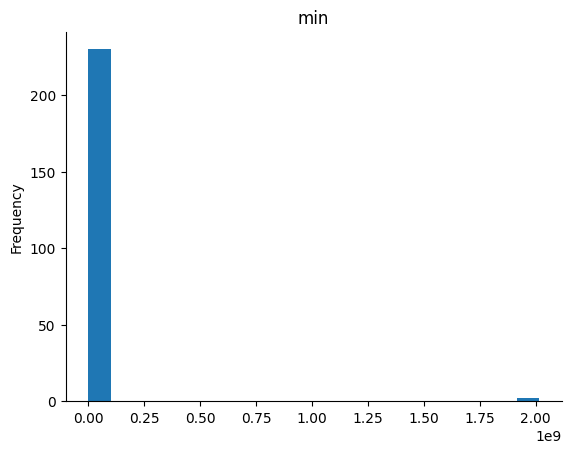

In [ ]:
from matplotlib import pyplot as plt
_df_3['min'].plot(kind='hist', bins=20, title='min')
plt.gca().spines[['top', 'right',]].set_visible(False)

##Pretratamiento de los datos

In [ ]:
#Primer cribado:
#Se eliminan algunas características que no aportan valor al modelo (razonado en el documento: XXXXXXXX)
columnas_para_eliminar = '''
_STATE, FMONTH, IDATE, IMONTH, IDAY, IYEAR, DISPCODE, SEQNO, _PSU, QSTVER, QSTLANG, MSCODE, _STSTR, _STRWT, _RAWRAKE, _WT2RAKE, _CLLCPWT, _DUALUSE, _DUALCOR, _LLCPWT,
CTELENUM, CELLFON3, CTELNUM1, CELLFON2, CADULT, CCLGHOUS, CSTATE, LANDLINE, NUMPHON2, CPDEMO1, INTERNET, PVTRESD1, COLGHOUS, STATERES, LADULT, NUMADULT, NUMMEN, NUMWOMEN,
PVTRESD2, HHADULT, RENTHOM1, NUMHHOL2, CHILDREN, INCOME2, CDHELP, CDSOCIAL, _CHLDCNT, _INCOMG, DIABAGE2, PDIABTST, PREDIAB1, INSULIN, FEETCHK2, DOCTDIAB, CHKHEMO3, FEETCHK,
EYEEXAM, DIABEYE, DIABEDU, MARITAL, EDUCA, VETERAN3, EMPLOY1, SEATBELT, CDDISCUS, SCNTMNY1, SCNTMEL1, SCNTPAID, SCNTWRK1, SCNTLPAD, SCNTLWK1, SXORIENT, TRNSGNDR, RCSGENDR,
RCSRLTN2, EMTSUPRT, LSATISFY, ADPLEASR, ADDOWN, MISTMNT, _EDUCAG, _RFSEAT2, _RFSEAT3, _LMTWRK1, _LMTSCL1, CAREGIV1, CRGVREL1, CRGVLNG1, CRGVHRS1, CRGVPRB1, CRGVPERS, CRGVHOUS,
CRGVMST2, CRGVEXPT, CDHOUSE, CDASSIST, WEIGHT2, HEIGHT3, HTIN4, HTM4, WTKG3, _BMI5, _RFBMI5, STOPSMK2, LASTSMK2, USENOW3, _SMOKER3, _RFSMOK3, ALCDAY5, DRNK3GE5, MAXDRNKS, DRNKANY5,
DROCDY3_, _RFBING5, _DRNKWEK, _RFDRHV5, FVGREEN, FVORANG, VEGETAB1, GRENDAY_, ORNGDAY_, VEGEDA1_, _MISVEGN, _VEGLT1, _VEG23, _VEGETEX, FTJUDA1_, FRUTDA1_, FRUITJU1, FRUIT1, _MISFRTN,
_FRTLT1, _FRT16, _FRUITEX, FVBEANS,  EXERANY2, EXRACT11, EXRACT21, EXEROFT2, EXERHMM2, ADMOVE, EXACTOT1, EXACTOT2, _TOTINDA, METVL11_, METVL21_, MAXVO2_, FC60_, ACTIN11_, ACTIN21_,
PADUR1_, PADUR2_, PAFREQ1_, PAFREQ2_, _MINAC11, _MINAC21, STRFREQ_, PAMIN11_, PAMIN21_, PA1MIN_, PAVIG11_, PAVIG21_, PA1VIGM_, _PA150R2, _PA300R2, _PA30021, _PASTRNG, _PAREC1,
_PASTAE1, _LMTACT1, LMTJOIN3, ARTHSOCL, JOINPAIN, PAINACT2, TOLDHI2, QLMENTL2, QLHLTH2, _RFHLTH, VIDFCLT2, VIREDIF3, VIPRFVS2, VINOCRE2, VIEYEXM2, VIINSUR2, VICTRCT4, VIGLUMA2,
VIMACDG2, ASTHMAGE, ASATTACK, ASERVIST, ASDRVIST, ASRCHKUP, ASACTLIM, ASYMPTOM, ASNOSLEP, ASTHMED3, ASINHALR, CASTHDX2, CASTHNO2, _LTASTH1, _CASTHM1, _ASTHMS1, HAREHAB1,
STREHAB1, CVDASPRN, ASPUNSAF, _MICHD, RLIVPAIN, RDUCHART, RDUCSTRK, ARTTODAY, ARTHWGT, ARTHEXER, ARTHEDU, _DRDXAR1, _RFCHOL,  _CHISPNC, _CRACE1, _CPRACE, _PRACE1, _MRACE1, _HISPANC,
_RACEG21, _RACEGR3, _RACE_G1, _AGE65YR, _AGE80, _AGE_G, _RFHYPE5, CHOLCHK, HIVTST6, HIVTSTD3, WHRTST10, HADMAM, HOWLONG, HADPAP2, LASTPAP2, HPVTEST, HPLSTTST, HADHYST2, PROFEXAM,
LENGEXAM, BLDSTOOL, LSTBLDS3, HADSIGM3, HADSGCO1, LASTSIG3, PSATEST1, PSATIME, PCPSARS1, PCPSADE1, PCDMDECN, _AIDTST3, _CHOLCHK, FLUSHOT6, FLSHTMY2, IMFVPLAC, PNEUVAC3, TETANUS,
HPVADVC2, HPVADSHT, SHINGLE2, _FLSHOT6, _PNEUMO2
'''
#Elimina los saltos de línea
columnas_para_eliminar = columnas_para_eliminar.replace("\n", "")
#Elimina espacios que pueda haber en las variables
columnas_para_eliminar = columnas_para_eliminar.replace(" ", "")
#Obtención de una lista a partir de un string
columnas_eliminar = columnas_para_eliminar.split(',')

#De las 330 columnas, se eliminarán 101 por lo que se tendría que tener un nuevo df de 229 columnas
print(f'Número de columnas a eliminar: {len(columnas_eliminar)}')
print(f'Columnas a eliminar únicas: {len(set(columnas_eliminar))}')

#Primero se crea una compia del df original
dataset_v1 = dataset_original.copy()

#Se comprueba que todas las columnas existen en el df y se incluye una que no existe "prueba" para probar el código
columnas_no_existentes = [col for col in columnas_eliminar if col not in dataset_v1.columns]
if columnas_no_existentes:
    print("Las siguientes columnas NO existen en el DataFrame:")
    for col in columnas_no_existentes:
        print(col)
else:
    print('Todas las columnas existen en el DataFrame')

#Se eliminan las columnas de la lista. Incluyendo errors='ignore' no sería necesario hacer el paso previo. Se comprueba que efectivamente se tienen 229 columnas
dataset_v1 = dataset_v1.drop(columns=columnas_eliminar, errors='ignore')
dataset_v1.info()

Número de columnas a eliminar: 264
Columnas a eliminar únicas: 264
Todas las columnas existen en el DataFrame
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 66 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   GENHLTH   1705 non-null   float64
 1   PHYSHLTH  1705 non-null   float64
 2   MENTHLTH  1705 non-null   float64
 3   POORHLTH  939 non-null    float64
 4   HLTHPLN1  1705 non-null   float64
 5   PERSDOC2  1705 non-null   float64
 6   MEDCOST   1705 non-null   float64
 7   CHECKUP1  1705 non-null   float64
 8   BPHIGH4   1705 non-null   float64
 9   BPMEDS    989 non-null    float64
 10  BLOODCHO  1705 non-null   float64
 11  CVDINFR4  1705 non-null   float64
 12  CVDCRHD4  1705 non-null   float64
 13  CVDSTRK3  1705 non-null   float64
 14  ASTHMA3   1705 non-null   float64
 15  ASTHNOW   252 non-null    float64
 16  CHCSCNCR  1705 non-null   float64
 17  CHCOCNCR  1705 non-null   float64
 18